In [1]:
import transformers
import shap
import torch

d:\vscode\MoodLens-AI\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
# 1. Load your saved model and tokenizer
model_path = "../models/emotion_model"
tokenizer = transformers.AutoTokenizer.from_pretrained(model_path)
model = transformers.AutoModelForSequenceClassification.from_pretrained(model_path)

# Map class indices to exact emotion names so pipeline/SHAP doesn't show LABEL_*.
emotion_by_id = {
    0: 'sadness',
    1: 'joy',
    2: 'love',
    3: 'anger',
    4: 'fear',
    5: 'surprise',
}
model.config.id2label = emotion_by_id
model.config.label2id = {v: k for k, v in emotion_by_id.items()}

# Ensure the model is on the correct device (GPU if available)
device = 0 if torch.cuda.is_available() else -1
if device == 0:
    model.cuda()

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4571.41it/s]


In [19]:
# 2. Create a prediction pipeline
# 'return_all_scores=True' allows SHAP to explain all emotion classes
pred_pipeline = transformers.pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=device,
    return_all_scores=True
)

In [24]:
# 3. Initialize the SHAP Explainer
# The Explainer automatically handles transformer pipelines
explainer = shap.Explainer(pred_pipeline)
#explainer = shap.Explainer(shap.models.TransformersPipeline(pred_pipeline, rescale_to_logits=True))

In [25]:
# 4. Define the text you want to explain
test_text = ["I am feeling so happy today!", "This situation is very frustrating."]


In [26]:
# 5. Compute SHAP values
shap_values = explainer(test_text)

PartitionExplainer explainer: 3it [00:12, 12.68s/it]               


In [ ]:
# 6. Show SHAP plot only for the predicted emotion
scores = pred_pipeline(test_text[0])
if isinstance(scores[0], list):
    scores = scores[0]
predicted_emotion = max(scores, key=lambda x: x["score"])["label"]
print(f"Predicted emotion: {predicted_emotion}")
shap.plots.bar(shap_values[0, :, predicted_emotion])

Predicted emotion: joy


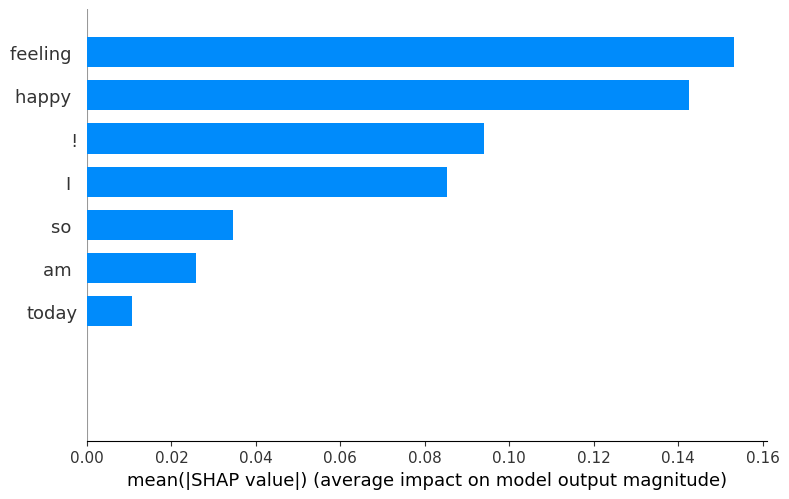

In [39]:
# Very simple summary plot for the predicted emotion
import numpy as np

pred_scores = pred_pipeline(test_text[0])
if isinstance(pred_scores[0], list):
    pred_scores = pred_scores[0]

predicted_label = max(pred_scores, key=lambda x: x['score'])['label']
print('Predicted emotion:', predicted_label)

class_idx = model.config.label2id[predicted_label]
exp = shap_values[0, :, class_idx]

shap.summary_plot(
    np.array([exp.values]),
    feature_names=[str(token) for token in exp.data],
    plot_type='bar'
 )